In [1]:
import matplotlib.pyplot as plt

from pydrake.all import (
    DiagramBuilder,
    MultibodyPlant,
    Simulator,
    StartMeshcat,
    LogVectorOutput,
    VectorLog,
)

from manipulation.station import LoadScenario, MakeHardwareStation

In [2]:
meshcat = StartMeshcat()

INFO:drake:Meshcat listening for connections at http://localhost:7002


In [3]:
def create_joint_limit_finder(
    joint_name: str,
    fixed_link_name: str,
    fixed_link_rotation_deg: list[int],
    q_init: list[float]
) -> tuple[Simulator, VectorLog]:
    scenario_data = f"""
    directives:
    - add_model:
        name: so101
        file: file:///home/noor/so101-drake/models/SO101/{joint_name}.urdf
    - add_weld:
        parent: world
        child: so101::{fixed_link_name}
        X_PC:
            translation: [0, 0, 0]
            rotation: !Rpy {{ deg: {fixed_link_rotation_deg} }}
    plant_config:
        time_step: 1e-3
        adjacent_bodies_collision_filters: False
    """

    builder = DiagramBuilder()

    scenario = LoadScenario(data=scenario_data)
    station = MakeHardwareStation(scenario, meshcat)
    station = builder.AddSystem(station)

    state_logger = LogVectorOutput(
        station.GetOutputPort("so101_state"), 
        builder
    )

    diagram = builder.Build()

    simulator = Simulator(diagram)
    simulator.set_target_realtime_rate(1.0)

    context = simulator.get_mutable_context()
    plant: MultibodyPlant = station.GetSubsystemByName("plant")
    plant_context = plant.GetMyContextFromRoot(context)
    plant.SetPositions(plant_context, q_init)

    state_log = state_logger.FindLog(context)

    return simulator, state_log

joint limit: -2.01013 radians


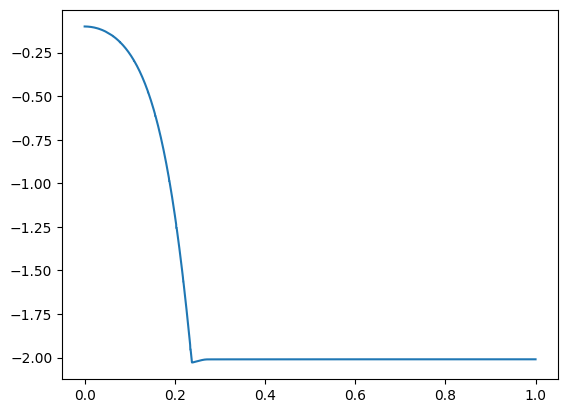

In [10]:
simulator, state_log = create_joint_limit_finder(
    joint_name="shoulder_pan",
    fixed_link_name="base_link",
    fixed_link_rotation_deg=[0, -90, 0],
    q_init=[-0.1]
)
# simulator, state_log = create_joint_limit_finder(
#     joint_name="shoulder_lift",
#     fixed_link_name="shoulder_link",
#     fixed_link_rotation_deg=[0, 180, 0],
#     q_init=[-0.1]
# )
# simulator, state_log = create_joint_limit_finder(
#     joint_name="elbow_flex",
#     fixed_link_name="shoulder_link",
#     fixed_link_rotation_deg=[0, 180, 0],
#     q_init=[-1.0, 0.0]
# )
# simulator, state_log = create_joint_limit_finder(
#     joint_name="wrist_flex",
#     fixed_link_name="lower_arm_link",
#     fixed_link_rotation_deg=[0, 90, 0],
#     q_init=[-0.1]
# )
# simulator, state_log = create_joint_limit_finder(
#     joint_name="gripper",
#     fixed_link_name="gripper_link",
#     fixed_link_rotation_deg=[0, -90, 0],
#     q_init=[-0.1]
# )

meshcat.StartRecording()
simulator.AdvanceTo(1.0)
meshcat.StopRecording()
meshcat.PublishRecording()

joint_limt = round(state_log.data()[0, -1], 5) # change 0 to 1 for elbow_flex
print(f'joint limit: {joint_limt} radians')
plt.plot(state_log.sample_times(), state_log.data()[0]) # change 0 to 1 for elbow_flex